In [19]:
import numpy as np
import sympy
import string
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib import rcParams
import pandas as pd
import csv
from os.path import join as pjoin
from tqdm import tqdm
from matplotlib.lines import Line2D
import re
import os

from utils import OperonArgs
import sys
import sr_fun

from processing_fun import find_nearest, string_to_list
sys.path.insert(0, '../literature_fits')
from attenuation_curves import Att_Curve_2param, Li_08_fit_noratio

plt.rcParams['font.size'] = 14

In [2]:
ini_file = 'conf/iob_6.ini'
ilen = 32

# Compare to literature


Reading from configuration file: conf/iob_6.ini

Comparing to literature for train data...
Using Av column: A_5542A
Using 1500 galaxies with Av all.


100%|██████████| 1500/1500 [00:01<00:00, 1174.18it/s]


	No subsampling of wavelengths
	Median Absolute Deviation of dF/F for 2-parameter fit on training data: 0.019984314990335594
	Median Absolute Deviation of dF/F for 4-parameter fit on training data: 0.014659152885297122
	Median Absolute Deviation of dF/F for SR fit on training data: 0.021281794058404246

	Low wavelengths:
	Median Absolute Deviation of dF/F for 2-parameter fit on training data: 0.022276946436274925
	Median Absolute Deviation of dF/F for 4-parameter fit on training data: 0.022421614969206083
	Median Absolute Deviation of dF/F for SR fit on training data: 0.024222566358016562

Comparing to literature for val data...
Using Av column: A_5542A
Using 750 galaxies with Av all.


100%|██████████| 750/750 [00:00<00:00, 1203.74it/s]


	No subsampling of wavelengths
	Median Absolute Deviation of dF/F for 2-parameter fit on training data: 0.020371770248020782
	Median Absolute Deviation of dF/F for 4-parameter fit on training data: 0.015035456517935586
	Median Absolute Deviation of dF/F for SR fit on training data: 0.022038655157028186

	Low wavelengths:
	Median Absolute Deviation of dF/F for 2-parameter fit on training data: 0.02304813642686432
	Median Absolute Deviation of dF/F for 4-parameter fit on training data: 0.023629596250956675
	Median Absolute Deviation of dF/F for SR fit on training data: 0.02426806688428762


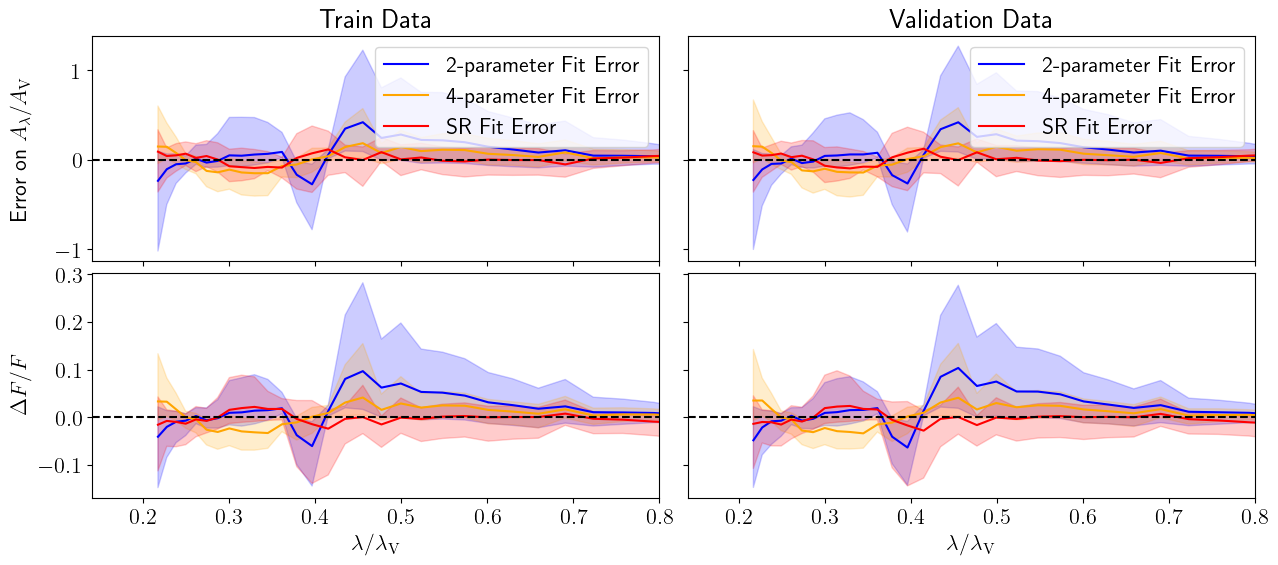

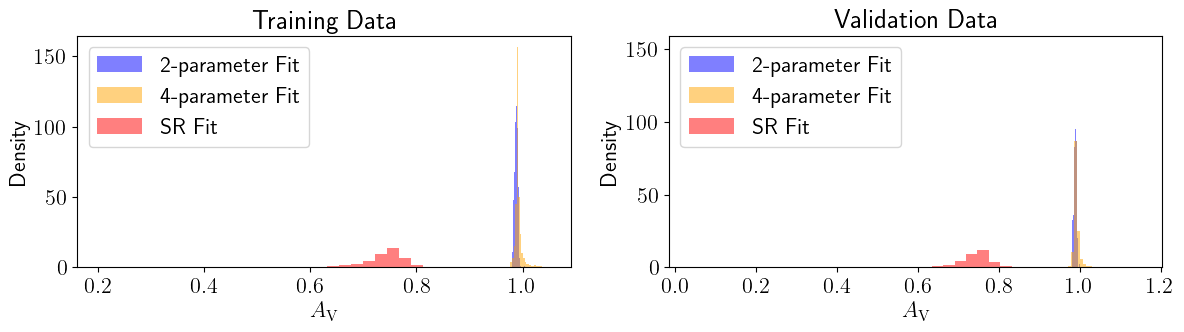

In [43]:
def compare_to_literature(ini_file, ilen=None, which_gals='all', use_optimised=False):
    """
    Compare the errors from the operon run to the literature fits
    
    Args:
        :ini_file (str): The path to the ini file containing the run information
        :ilen (int, default=None): The length of the equation to highlight. If None,
            then this is taken to be the final equation
            
    Returns:
        :fig (matplotlib.figure.Figure): Figure containing plot
        :axs (np.ndarray[matplotlib.pyplot.axis]): Axes of fig containing the plot
        :which_gals (str, default='all'): The galaxies to be used in the comparison. 'all' for all galaxies, 
            'low' for galaxies with Av < 0.2, or 'high' for galaxies with Av > 0.7.
        :use_optimised (bool, default=False): Whether to use the optimised attenuation curves for the operon
            fit or the original ones (the latter is the default and uses the IOB parameters).
    """
    
    args = OperonArgs(ini_file)

    run_name = f'{args.in_param}_{str(args.version_num)}'
    out_dir = pjoin(args.fit_dir, run_name)
    fname = f'{out_dir}/{run_name}_fun.csv'
    df = pd.read_csv(fname, delimiter=';')
    if ilen is None:
        eq_idx = -1
    else:
        eq_idx = list(df['Length']).index(ilen)
    length = list(df['Length'])[eq_idx]

    
    # all_data = all_data.drop_duplicates(subset=["galaxy_id", "los"])

    fig, axs = plt.subplots(2, 2, figsize=(15, 6), sharex=True, sharey='row')
    fig2, axs2 = plt.subplots(1, 2, figsize=(14, 3),)

    for r, name in enumerate(['train', 'val']):

        print(f'\nComparing to literature for {name} data...')

        all_data = pd.read_csv(args.input_file, sep='\t')

        # Load required data
        matches = pd.read_csv(os.path.join(args.data_dir, f'{args.in_param}_data_{args.version_num}', f'iob_{name}_galaxy_ids_los.txt'), sep='\t')
        matches.rename(columns={"# galaxy_id": "galaxy_id"}, inplace=True)
        data = all_data.merge(matches, on=['galaxy_id', 'los'], how='inner')
        fit_data = pd.read_csv(os.path.join(os.path.dirname(args.input_file), "galaxy_optimization_results.csv"))
        fit_data.rename(columns={"gal_id": "galaxy_id"}, inplace=True)
        data = data.merge(fit_data, on=['galaxy_id', 'los'], how='inner')
        data = data.drop_duplicates(subset=["galaxy_id", "los"])

        # Identify attenuation columns (formatted like A_1000A)
        attenuation_cols = [col for col in data.columns if re.match(r'A_\d+A', col)]
        lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
        sort_idx = np.argsort(lam_arr)
        lam_arr = lam_arr[sort_idx]
        attenuation_cols = [attenuation_cols[i] for i in sort_idx]
        mask = (lam_arr < args.lam_max) & (lam_arr > args.lam_min)
        lam_arr = lam_arr[mask]
        attenuation_cols = [attenuation_cols[i] for i in range(len(attenuation_cols)) if mask[i]]

        v_index = find_nearest(lam_arr, args.lambda_V)
        Av_name = attenuation_cols[v_index]
        print(f'Using Av column: {Av_name}')

        # Get mask for operon fit later
        if not use_optimised:
            operon_mask = np.zeros(len(data['galaxy_id']), dtype=bool)
            for i, (gid, los) in enumerate(matches[['galaxy_id', 'los']].values):
                m = (data['galaxy_id'] == gid) & (data['los'] == los)
                Av = data[Av_name][m].values[0]
                if which_gals == 'low' and Av < 0.2:
                    operon_mask[i] = True
                elif which_gals == 'high' and Av > 0.7:
                    operon_mask[i] = True
                elif which_gals == 'all':
                    operon_mask[i] = True
            

        # Select galaxies based on Av
        if which_gals == 'low':
            mask = (data[Av_name] < 0.2)
        elif which_gals == 'high':
            mask = (data[Av_name] > 0.7)
        elif which_gals == 'all':
            mask = np.ones(len(data), dtype=bool)
        else:
            raise ValueError("Invalid value for 'which_gals'. Choose from 'all', 'low', or 'high'.")
        data = data[mask]
        print(f'Using {len(data)} galaxies with Av {which_gals}.')

        A_err_2par = np.zeros((len(data['galaxy_id']), len(lam_arr)))
        A_err_4par = np.zeros((len(data['galaxy_id']), len(lam_arr)))
        df_F_2par = np.zeros((len(data['galaxy_id']), len(lam_arr)))
        df_F_4par = np.zeros((len(data['galaxy_id']), len(lam_arr)))
        A_at_lv_2par = np.zeros(len(data['galaxy_id']))
        A_at_lv_4par = np.zeros(len(data['galaxy_id']))


        for i in tqdm(range(len(data['galaxy_id']))):

            popt_2par = string_to_list(data['popt_2par'].iloc[i])
            popt_4par = string_to_list(data['popt_4par'].iloc[i])
            Alam_arr_cut = data[attenuation_cols].iloc[i].values.flatten()

            Av = Alam_arr_cut[v_index]
            Alam_Av_arr_cut = Alam_arr_cut/Av
            lam_cut = lam_arr
            
            fit_4par = Li_08_fit_noratio(lam_cut, *popt_4par)
            fit_2par = Att_Curve_2param(1e4*lam_cut, *popt_2par)

            df_F_2par[i] = 10. ** (0.4 * Av * (Alam_Av_arr_cut - fit_2par)) - 1.0
            df_F_4par[i] = 10. ** (0.4 * Av * (Alam_Av_arr_cut - fit_4par)) - 1.0

            A_err_2par[i] = Alam_Av_arr_cut - fit_2par
            A_err_4par[i] = Alam_Av_arr_cut - fit_4par

            A_at_lv_2par[i] = fit_2par[v_index]
            A_at_lv_4par[i] = fit_4par[v_index]


        mask_low_lambda_lit = (lam_cut < 0.4 * args.lambda_V)

        axs[0,r].plot(lam_cut/args.lambda_V, np.median(A_err_2par, axis=0), label='2-parameter Fit Error', color='blue')
        axs[0,r].fill_between(lam_cut/args.lambda_V, 
                            np.percentile(A_err_2par, 16, axis=0), 
                            np.percentile(A_err_2par, 84, axis=0), 
                            color='blue', alpha=0.2)
        sigma = np.maximum(np.abs(np.percentile(A_err_2par, 16, axis=0)), np.abs(np.percentile(A_err_2par, 84, axis=0)))
        # axs[2,r].plot(lam_cut/args.lambda_V, sigma, label='2-parameter Fit Error', color='blue')

        axs[0,r].plot(lam_cut/args.lambda_V, np.median(A_err_4par, axis=0), label='4-parameter Fit Error', color='orange')
        axs[0,r].fill_between(lam_cut/args.lambda_V, 
                            np.percentile(A_err_4par, 16, axis=0), 
                            np.percentile(A_err_4par, 84, axis=0), 
                            color='orange', alpha=0.2)
        sigma = np.maximum(np.abs(np.percentile(A_err_4par, 16, axis=0)), np.abs(np.percentile(A_err_4par, 84, axis=0)))
        # axs[2,r].plot(lam_cut/args.lambda_V, sigma, label='4-parameter Fit Error', color='orange')

        axs[1,r].plot(lam_cut/args.lambda_V, np.median(df_F_2par, axis=0), label='2-parameter Fit Error', color='blue')
        axs[1,r].fill_between(lam_cut/args.lambda_V, 
                            np.percentile(df_F_2par, 16, axis=0), 
                            np.percentile(df_F_2par, 84, axis=0), 
                            color='blue', alpha=0.2)
        sigma = np.maximum(np.abs(np.percentile(df_F_2par, 16, axis=0)), np.abs(np.percentile(df_F_2par, 84, axis=0)))
        # axs[3,r].plot(lam_cut/args.lambda_V, sigma, label='2-parameter Fit Error', color='blue')

        axs[1,r].plot(lam_cut/args.lambda_V, np.median(df_F_4par, axis=0), label='4-parameter Fit Error', color='orange')
        axs[1,r].fill_between(lam_cut/args.lambda_V, 
                            np.percentile(df_F_4par, 16, axis=0), 
                            np.percentile(df_F_4par, 84, axis=0), 
                            color='orange', alpha=0.2)
        sigma = np.maximum(np.abs(np.percentile(df_F_4par, 16, axis=0)), np.abs(np.percentile(df_F_4par, 84, axis=0)))
        # axs[3,r].plot(lam_cut/args.lambda_V, sigma, label='4-parameter Fit Error', color='orange')

        axs2[r].hist(A_at_lv_2par, bins=30, density=True, alpha=0.5, label='2-parameter Fit', color='blue')
        axs2[r].hist(A_at_lv_4par, bins=30, density=True, alpha=0.5, label='4-parameter Fit', color='orange')

        if use_optimised:

            # Load required data
            matches = pd.read_csv(os.path.join(args.data_dir, f'{args.in_param}_data_{args.version_num}', f'iob_{name}_galaxy_ids_los.txt'), sep='\t')
            matches.rename(columns={"# galaxy_id": "galaxy_id"}, inplace=True)
            data = all_data.merge(matches, on=['galaxy_id', 'los'], how='inner')
            fit_data = pd.read_csv(os.path.join(os.path.dirname(args.input_file), "galaxy_sr_optimization_results.csv"))
            fit_data.rename(columns={"gal_id": "galaxy_id"}, inplace=True)
            data = data.merge(fit_data, on=['galaxy_id', 'los'], how='inner')
            data = data.drop_duplicates(subset=["galaxy_id", "los"])

            # Identify attenuation columns (formatted like A_1000A)
            attenuation_cols = [col for col in data.columns if re.match(r'A_\d+A', col)]
            lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
            sort_idx = np.argsort(lam_arr)
            lam_arr = lam_arr[sort_idx]
            attenuation_cols = [attenuation_cols[i] for i in sort_idx]
            mask = (lam_arr < args.lam_max) & (lam_arr > args.lam_min)
            lam_arr = lam_arr[mask]
            attenuation_cols = [attenuation_cols[i] for i in range(len(attenuation_cols)) if mask[i]]
            lam_cut = lam_arr

            v_index = find_nearest(lam_arr, args.lambda_V)
            Av_name = attenuation_cols[v_index]

            # Select galaxies based on Av
            if which_gals == 'low':
                mask = (data[Av_name] < 0.2)
            elif which_gals == 'high':
                mask = (data[Av_name] > 0.7)
            elif which_gals == 'all':
                mask = np.ones(len(data), dtype=bool)
            else:
                raise ValueError("Invalid value for 'which_gals'. Choose from 'all', 'low', or 'high'.")
            data = data[mask]

            A_err_op = np.zeros((len(data['galaxy_id']), len(lam_arr)))
            df_F_op = np.zeros((len(data['galaxy_id']), len(lam_arr)))
            A_at_lv_op = np.zeros(len(data['galaxy_id']))

            for i in tqdm(range(len(data['galaxy_id']))):

                popt = string_to_list(data['popt'].iloc[i])
                Alam_arr_cut = data[attenuation_cols].iloc[i].values.flatten()

                Av = Alam_arr_cut[v_index]
                Alam_Av_arr_cut = Alam_arr_cut/Av
                fit_op = sr_fun.compute_Av(lam_cut / lam_arr[v_index], *popt)
                
                df_F_op[i] = 10. ** (0.4 * Av * (Alam_Av_arr_cut - fit_op)) - 1.0
                A_err_op[i] = Alam_Av_arr_cut - fit_op

                A_at_lv_op[i] = fit_op[v_index]

        else:

            assert operon_mask.sum() == len(data), "Operon mask does not match the number of galaxies in the data."
            fname= f'{out_dir}/{run_name}_{name}_{length}.csv'
            data = np.loadtxt(fname)
            ytrue = data[:,args.npar+1]
            ypred = data[:,args.npar+2]
            if args.fit_log:
                ypred = 10. ** ypred
                ytrue = 10. ** ytrue
            fname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}', f'{args.in_param}_train_data.txt')
            with open(fname, 'r') as f:
                header = f.readline().split()
            lam = np.unique(np.loadtxt(fname, skiprows=1)[:,header.index('lam')])
            A_err_op = [None] * getattr(args, f'n{name}')
            df_F_op = [None] * getattr(args, f'n{name}')
            A_at_lv_op = [None] * getattr(args, f'n{name}')
            for j in range(getattr(args, f'n{name}')):
                A_err_op[j] = ypred[j*len(lam):(j+1)*len(lam)] - ytrue[j*len(lam):(j+1)*len(lam)]
                df_F_op[j] = data[j*len(lam):(j+1)*len(lam),args.npar+3]
                A_at_lv_op[j] = ypred[j*len(lam):(j+1)*len(lam)][v_index]
            A_err_op = np.array(A_err_op)[operon_mask]
            df_F_op = np.array(df_F_op)[operon_mask]

        # Subsample wavelengths if specified
        if args.lambda_trans is not None and args.f_subsample is not None:
            print(f'\tSubsampling wavelengths above {args.lambda_trans} by a factor of {args.f_subsample}')
            lambda_trans = args.lambda_trans #/ args.lambda_V
            mask_below = lam_cut < lambda_trans
            idx_above = np.nonzero(lam_cut >= lambda_trans)[0]
            mask_above = np.zeros_like(mask_below)
            mask_above[idx_above[::args.f_subsample]] = True
            mask = mask_below | mask_above
            lam_cut_sub = lam_cut[mask]
            print('\tSubsampled wavelengths:', lam_cut_sub)
            print('\tNumber of wavelengths after subsampling:', len(lam_cut_sub), 'from', len(mask))
        else:
            lam_cut_sub = lam_cut
            print('\tNo subsampling of wavelengths')

        mask_low_lambda_op = (lam_cut_sub < 0.4 * args.lambda_V)

        c = 'red'
        axs[0,r].plot(lam_cut_sub/args.lambda_V, np.median(A_err_op, axis=0), label='SR Fit Error', color=c)
        axs[0,r].fill_between(lam_cut_sub/args.lambda_V, 
                            np.percentile(A_err_op, 16, axis=0), 
                            np.percentile(A_err_op, 84, axis=0), 
                            color=c, alpha=0.2)
        sigma = np.maximum(np.abs(np.percentile(A_err_op, 16, axis=0)), np.abs(np.percentile(A_err_op, 84, axis=0)))
        # axs[2,r].plot(lam_cut_sub/args.lambda_V, sigma, label='SR Fit Error', color=c)

        axs[1,r].plot(lam_cut_sub/args.lambda_V, np.median(df_F_op, axis=0), label='SR Fit Error', color=c)
        axs[1,r].fill_between(lam_cut_sub/args.lambda_V, 
                            np.percentile(df_F_op, 16, axis=0), 
                            np.percentile(df_F_op, 84, axis=0), 
                            color=c, alpha=0.2)
        sigma = np.maximum(np.abs(np.percentile(df_F_op, 16, axis=0)), np.abs(np.percentile(df_F_op, 84, axis=0)))
        # axs[3,r].plot(lam_cut_sub/args.lambda_V, sigma, label='SR Fit Error', color=c)

        axs2[r].hist(A_at_lv_op, bins=30, density=True, alpha=0.5, label='SR Fit', color=c)

        axs[0,0].set_ylabel(r'Error on $A_\lambda / A_{\rm V}$')
        axs[0,r].axhline(0, color='black', ls='--')
        axs[1,0].set_ylabel(r'$\Delta F / F$')
        axs[1,r].axhline(0, color='black', ls='--')
        # axs[2,r].set_ylabel(r'Error on $A_\lambda / A_{\rm V}$ (sigma)')
        # axs[3,r].set_ylabel(r'$\Delta F / F$ (sigma)')

        for ax in axs[:,r]:
            # ax.axvline(1.0, color='k', linestyle=':')
            # xmax = 0.8 * args.lambda_V
            ax.set_xlim(None, 0.8)

        axs2[r].set_xlabel(r'$A_{\rm V}$')
        axs2[r].set_ylabel('Density')
        axs2[r].legend()
        axs2[0].set_title('Training Data')
        axs2[1].set_title('Validation Data')

        if name == 'val':
            axs[0,r].set_title('Validation Data')
        else:
            axs[0,r].set_title(f'{name.capitalize()} Data')
        axs[-1,r].set_xlabel(r'$\lambda / \lambda_{\rm V}$')
        axs[0,r].legend()

        for ax in axs[2:,r]:
            ax.set_ylim(0, None)


        medae_F_2par = float(np.median(np.abs(df_F_2par)))
        medae_F_4par = float(np.median(np.abs(df_F_4par)))
        medae_F_op = float(np.median(np.abs(df_F_op)))

        print(f"\tMedian Absolute Deviation of dF/F for 2-parameter fit on training data: {medae_F_2par}")
        print(f"\tMedian Absolute Deviation of dF/F for 4-parameter fit on training data: {medae_F_4par}")
        print(f"\tMedian Absolute Deviation of dF/F for SR fit on training data: {medae_F_op}")

        # Now do this for low wavelengths only
        medae_F_2par = float(np.median(np.abs(df_F_2par[:,mask_low_lambda_lit])))
        medae_F_4par = float(np.median(np.abs(df_F_4par[:,mask_low_lambda_lit])))
        medae_F_op = float(np.median(np.abs(df_F_op[:,mask_low_lambda_op])))

        print("")
        print("\tLow wavelengths:")
        print(f"\tMedian Absolute Deviation of dF/F for 2-parameter fit on training data: {medae_F_2par}")
        print(f"\tMedian Absolute Deviation of dF/F for 4-parameter fit on training data: {medae_F_4par}")
        print(f"\tMedian Absolute Deviation of dF/F for SR fit on training data: {medae_F_op}")

    if args.lambda_trans is not None and args.f_subsample is not None:
        lambda_trans = args.lambda_trans / args.lambda_V
        for ax in axs.flatten():
            ax.axvline(lambda_trans, color='k', linestyle=':')

    fig.subplots_adjust(hspace=0.05, wspace=0.05)
    fig.align_labels()

    return fig, axs


fig, axs = compare_to_literature(ini_file, ilen=ilen, which_gals='all', use_optimised=False)
fig.savefig(f'figs/iob_6_compare_to_literature.png', dpi=300, bbox_inches='tight')


# Example Curves


Reading from configuration file: conf/iob_6.ini

Target: A
[0.00528542 0.00573096 0.00579151 0.00598104 0.00608196 0.00615764
 0.00654684 0.00656867 0.00665096 0.00668496]
[0.0061167  0.00633835 0.00637316 0.00672713 0.00672979 0.0067808
 0.00702577 0.00716474 0.00722624 0.00724716]


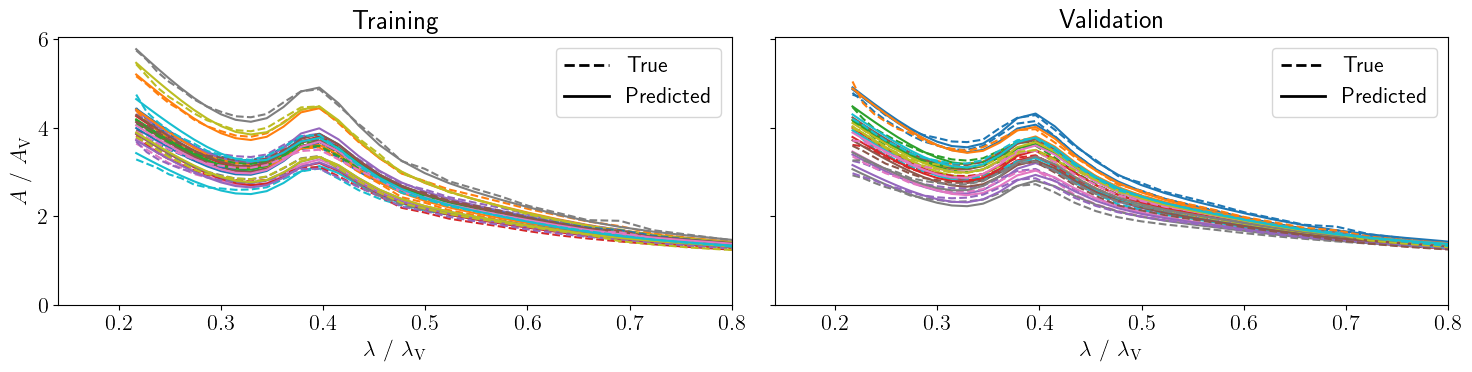

In [ ]:
def plot_example(ini_file, ilen=None, nexamples=5, plot_av_diff=True, plot_dF_F=True):
    """
    Plot an example curve
    
    Args:
        :ini_file (str): The path to the ini file containing the run information
        :ilen (int, default=None): The length of the equation to highlight. If None,
            then this is taken to be the final equation
        :nexamples (int, default=5): Number of examples to plot
        :offset (int, default=0): The offset in the examples to plot
        :plot_av_diff (bool, default=True): Whether to plot the difference between
            the true and predicted attenuation curve
        :plot_dF_F (bool, default=True): Whether to plot the dF/F values
            
    Returns:
        :fig (matplotlib.figure.Figure): Figure containing plot
        :axs (np.ndarray[matplotlib.pyplot.axis]): Axes of fig containing the plot
    """
    
    args = OperonArgs(ini_file)
    
    run_name = f'{args.in_param}_{str(args.version_num)}'
    out_dir = pjoin(args.fit_dir, run_name)
    fname = f'{out_dir}/{run_name}_fun.csv'
    df = pd.read_csv(fname, delimiter=';')
    
    if args.fit_log:
        print('\nTarget: log10A')
    else:
        print('\nTarget: A')
    
    if ilen is None:
        eq_idx = -1
    else:
        eq_idx = list(df['Length']).index(ilen)
    length = list(df['Length'])[eq_idx]
    
    rcParams['font.size'] = 16
    rcParams["text.usetex"] = True
        
    nrow = 1 + int(plot_av_diff) + int(plot_dF_F)
    fig, axs = plt.subplots(nrow, 2, figsize=(15,4*nrow), sharex=True, sharey='row')
    axs = np.atleast_2d(axs)

    for i, name in enumerate(['train', 'val']):

        fname= f'{out_dir}/{run_name}_{name}_{length}.csv'
        data = np.loadtxt(fname)
        ytrue = data[:,args.npar+1]
        ypred = data[:,args.npar+2]

        if data.shape[1] > args.npar+3:
            dF_F = data[:,args.npar+3]
        else:
            dF_F = np.full_like(ytrue, np.nan)
        
        if args.fit_log:
            ytrue = 10. ** ytrue
            ypred = 10. ** ypred

        # Get the galaxy ids and the los
        fname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}', f'{args.in_param}_{name}_galaxy_ids_los.txt')
        all_gal_id, all_los = np.loadtxt(fname, dtype=float, unpack=True, skiprows=1)
        
        fname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}', f'{args.in_param}_train_data.txt')
        with open(fname, 'r') as f:
            header = f.readline().split()
        lam = np.unique(np.loadtxt(fname, skiprows=1)[:,header.index('lam')])

        # Reshape ypred and ytrue to be (ngal, nlam)
        ytrue_reshaped = ytrue.reshape((-1, len(lam)))
        ypred_reshaped = ypred.reshape((-1, len(lam)))

        mse = np.mean((ypred_reshaped - ytrue_reshaped)**2, axis=1)
        sorted_indices = np.argsort(mse)
        print(mse[sorted_indices[:10]])
        
        for j, idx in enumerate(sorted_indices[:nexamples]):
            c = f'C{j}'
            t = ytrue_reshaped[idx]
            p = ypred_reshaped[idx]
            axs[0,i].plot(lam, t, color=c, ls='--')
            axs[0,i].plot(lam, p, color=c)
            if plot_av_diff:
                axs[1,i].plot(lam, t - p, color=c)
            if plot_dF_F:
                axs[2,i].plot(lam, dF_F[idx*len(lam):(idx+1)*len(lam)], color=c)

        if plot_av_diff:
            axs[1,i].axhline(0, color='k', ls='--', lw=2)
        if plot_dF_F:
            axs[2,i].axhline(0, color='k', ls='--', lw=2)
        axs[-1,i].set_xlabel(r'$\lambda \ / \ \lambda_{\rm V}$')
        axs[0,i].set_ylim(0, None)

    axs[0,0].set_ylabel(r'$A \ / \ A_{\rm V}$')
    if plot_av_diff:
        axs[1,0].set_ylabel(r'$\frac{A}{A_{\rm V}} - \left(\frac{A}{A_{\rm V}}\right)_{\rm pred}$')
    if plot_dF_F:
        axs[2,0].set_ylabel(r'$\Delta F/F$')
                
    custom_lines = [Line2D([0], [0], color='k', lw=2, ls='--'),
                Line2D([0], [0], color='k', lw=2, ls='-')]
    for ax in axs[0]:
        ax.legend(custom_lines, ['True', 'Predicted'])
    axs[0,0].set_title('Training')
    axs[0,1].set_title('Validation')

    if args.lambda_trans is not None and args.f_subsample is not None:
        lambda_trans = args.lambda_trans / args.lambda_V
        for ax in axs.flatten():
            ax.axvline(lambda_trans, color='k', linestyle=':')
        
    for ax in axs.flatten():
        ax.set_xlim(None, 0.8)

    fig.align_labels()
    fig.tight_layout()
    
    return fig, axs


fig, axs = plot_example(ini_file, ilen=ilen, nexamples=20, plot_av_diff=False, plot_dF_F=False);
fig.savefig(f'figs/iob_6_example_curves.png', dpi=300, bbox_inches='tight')